# 09. 시간대별 비교 — 역 근처의 감소는 어느 시간대에 컸나

**질문**: GTX가 통근 수요를 가져갔다면, 역 근처 셀의 감소는 **출근 시간대**에 커야 한다.

- 시간대: 새벽(00~05), 출근(06~09), 낮(10~15), 저녁(16~23). 모두 경기 승차 → 서울 하차 방향이다.
- 단위: 셀 × 시간대, 변화율 Poisson, 셀 군집 표준오차

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # 정리본 최상위의 config.py

from config import *
setup_notebook()

import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import norm

data = load_model_data()  # 1_받은코드_정리/output/model_dataset.csv
X_DUMMY = ["walk_20", "walk_20_60", "ic_access", "competing_share", "pop_20_50", "buildings"]

walk_group,20분 이내,20~60분,60분 초과
시간대,,,
새벽(00~05),-32.3,-14.0,62.0
출근(06~09),-39.3,-21.1,-10.3
낮(10~15),-46.2,-14.4,15.8
저녁(16~23),-12.8,-7.4,2.8


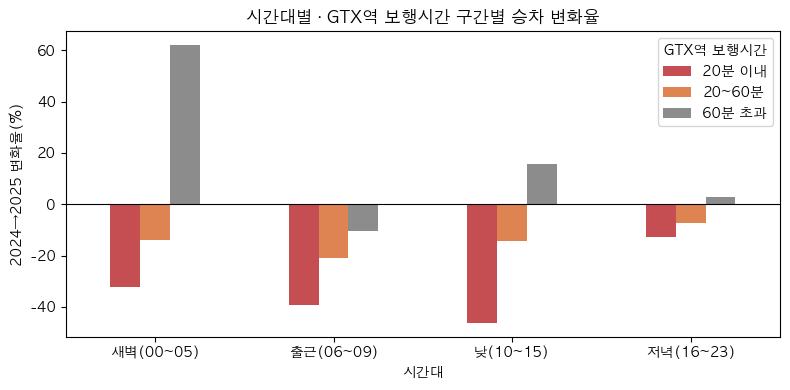

In [2]:
BANDS = pd.cut(range(24), [-1, 5, 9, 15, 23], labels=["새벽(00~05)", "출근(06~09)", "낮(10~15)", "저녁(16~23)"])
trips = load_trips().dropna(subset=["셀 ID"])
trips["시간대"] = pd.Categorical(trips["시"].map(dict(enumerate(BANDS))), categories=BANDS.categories, ordered=True)
band = (trips.pivot_table(index=["셀 ID", "시간대"], columns="연도", values="승차인원", aggfunc="sum", fill_value=0, observed=True)
        .reset_index().rename(columns={2024: "y2024", 2025: "y2025"}))
band["셀 ID"] = band["셀 ID"].astype(int)
band = band.merge(data[["셀 ID", "walk_group", "walk_20", "walk_20_60"]], on="셀 ID")

summary = band.groupby(["시간대", "walk_group"], observed=True)[["y2024", "y2025"]].sum()
summary["변화율(%)"] = (summary.y2025 / summary.y2024 - 1) * 100
table = summary["변화율(%)"].unstack().round(1)
display(table)

ax = table.plot.bar(figsize=(8, 4), rot=0, color=["#C44E52", "#DD8452", "#8C8C8C"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("2024→2025 변화율(%)")
ax.set_title("시간대별 · GTX역 보행시간 구간별 승차 변화율")
ax.legend(title="GTX역 보행시간")
plt.tight_layout()
plt.show()

In [3]:
# 시간대별로 20분 이내(vs 60분 초과) 효과를 따로 추정
rows = []
for name, frame in band[band.y2024 > 0].groupby("시간대", observed=True):
    result = poisson_rate(frame.y2025, frame.y2024, frame[["walk_20", "walk_20_60"]], cluster=frame["셀 ID"])
    rows.append({"시간대": name, "셀 수": len(frame), "2024 승차": frame.y2024.sum(),
                 "20분 이내 변화율 차이(%)": (np.exp(result.params["walk_20"]) - 1) * 100, "p (20분)": result.pvalues["walk_20"],
                 "20~60분 변화율 차이(%)": (np.exp(result.params["walk_20_60"]) - 1) * 100, "p (20~60분)": result.pvalues["walk_20_60"]})
pd.DataFrame(rows).round(4)

,시간대,셀 수,2024 승차,20분 이내 변화율 차이(%),p (20분),20~60분 변화율 차이(%),p (20~60분)
0,새벽(00~05),92,1467,-38.9394,0.0412,-25.7796,0.1603
1,출근(06~09),121,8822,-30.6143,0.0012,-9.7992,0.3978
2,낮(10~15),104,4842,-50.5206,0.0151,-21.4694,0.1352
3,저녁(16~23),100,4753,-11.2099,0.7642,-6.0124,0.7896


## 결론
- 20분 이내 셀의 감소는 **출근(06~09) −39%, 낮(10~15) −46%**로 크고, **저녁(16~23)은 −13%**로 작다. 60분 초과 셀 대비 차이도 출근(p = 0.001)·낮(p = 0.015)에서만 유의하고 저녁은 유의하지 않다(p = 0.76).
- 즉 **서울로 가는 주간 이동(출근 + 낮)에서 GTX로의 전환이 컸다**. 통근 수요가 GTX로 옮겨갔다는 해석과 맞는다.
- 저녁에 서울로 가는 수요(귀가가 아닌 저녁 약속 등)는 GTX 영향을 덜 받았다.
- 주의: 시간대별로 나누면 셀당 표본이 작아진다. 새벽은 승차 자체가 적어서(1,467명) 해석하지 않는다.